<a href="https://colab.research.google.com/github/novalrnv/machine_learning/blob/main/JS05/JS05-Tugas-Lab2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tugas Lab 2 - Naive Bayes dengan CountVectorizer vs TF-IDF

## Import Data

In [ ]:
import pandas as pd

df = pd.read_csv('spam.csv', encoding='latin-1')

# Drop kolom yang tidak digunakan
df = df.drop(df.iloc[:,2:], axis=1)

# Ganti nama kolom
df.columns = ['Labels', 'SMS']

# Encode label
df['Labels'] = df['Labels'].map({'spam': 1, 'ham': 0})

df.head()

,Labels,SMS
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [ ]:
X = df['SMS'].values
y = df['Labels'].values

print(df['Labels'].value_counts())

Labels
0    4825
1     747
Name: count, dtype: int64


In [ ]:
from sklearn.model_selection import train_test_split

# Split data training dan testing (sama untuk kedua soal agar perbandingan adil)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=50)

## Soal 1

Buatlah model klasifikasi Multinomial Naive Bayes dengan ketentuan:
1. Menggunakan data `spam.csv`
2. Fitur `CountVectorizer` dengan mengaktifkan **stop_words**
3. Evaluasi hasilnya

### Jawaban

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Ekstraksi fitur dengan CountVectorizer + stop_words
bow = CountVectorizer(stop_words='english')
X_train_bow = bow.fit_transform(X_train)
X_test_bow = bow.transform(X_test)

print(f'Jumlah fitur (CountVectorizer): {X_train_bow.shape[1]}')

Jumlah fitur (CountVectorizer): 7466


In [ ]:
# Training model
mnb_bow = MultinomialNB()
mnb_bow.fit(X_train_bow, y_train)

# Prediksi dan evaluasi
y_pred_bow = mnb_bow.predict(X_test_bow)
acc_bow = accuracy_score(y_test, y_pred_bow)

print('Akurasi (CountVectorizer):', acc_bow)
print('\nConfusion Matrix:\n', confusion_matrix(y_test, y_pred_bow))
print('\nLaporan Klasifikasi:\n', classification_report(y_test, y_pred_bow))

Akurasi (CountVectorizer): 0.9829596412556054

Confusion Matrix:
 [[951   3]
 [ 16 145]]

Laporan Klasifikasi:
               precision    recall  f1-score   support

           0       0.98      1.00      0.99       954
           1       0.98      0.90      0.94       161

    accuracy                           0.98      1115
   macro avg       0.98      0.95      0.96      1115
weighted avg       0.98      0.98      0.98      1115



Evaluasi:

Model Multinomial Naive Bayes dengan fitur `CountVectorizer` (stop_words aktif) menghasilkan akurasi testing sebesar **98.3%**, dengan precision dan recall yang tinggi pada kedua kelas (ham dan spam).

## Soal 2

Buatlah model klasifikasi Multinomial Naive Bayes dengan ketentuan:
1. Menggunakan data `spam.csv`
2. Fitur `TF-IDF` dengan mengaktifkan **stop_words**
3. Evaluasi hasilnya dan bandingkan dengan hasil pada Soal 1
4. Berikan kesimpulan fitur mana yang terbaik pada kasus data `spam.csv`

### Jawaban

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Ekstraksi fitur dengan TF-IDF + stop_words
tfidf = TfidfVectorizer(stop_words='english')
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print(f'Jumlah fitur (TF-IDF): {X_train_tfidf.shape[1]}')

Jumlah fitur (TF-IDF): 7466


In [ ]:
# Training model
mnb_tfidf = MultinomialNB()
mnb_tfidf.fit(X_train_tfidf, y_train)

# Prediksi dan evaluasi
y_pred_tfidf = mnb_tfidf.predict(X_test_tfidf)
acc_tfidf = accuracy_score(y_test, y_pred_tfidf)

print('Akurasi (TF-IDF):', acc_tfidf)
print('\nConfusion Matrix:\n', confusion_matrix(y_test, y_pred_tfidf))
print('\nLaporan Klasifikasi:\n', classification_report(y_test, y_pred_tfidf))

Akurasi (TF-IDF): 0.9605381165919282

Confusion Matrix:
 [[954   0]
 [ 44 117]]

Laporan Klasifikasi:
               precision    recall  f1-score   support

           0       0.96      1.00      0.98       954
           1       1.00      0.73      0.84       161

    accuracy                           0.96      1115
   macro avg       0.98      0.86      0.91      1115
weighted avg       0.96      0.96      0.96      1115



             Fitur   Akurasi
0  CountVectorizer  0.982960
1           TF-IDF  0.960538


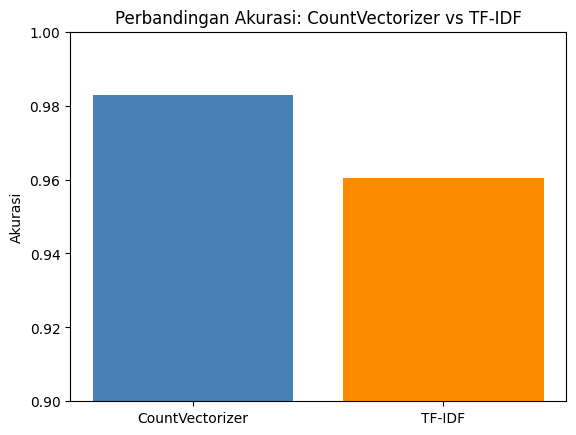

In [ ]:
perbandingan = pd.DataFrame({
    'Fitur': ['CountVectorizer', 'TF-IDF'],
    'Akurasi': [acc_bow, acc_tfidf]
})
print(perbandingan)

import matplotlib.pyplot as plt
plt.bar(perbandingan['Fitur'], perbandingan['Akurasi'], color=['steelblue', 'darkorange'])
plt.title('Perbandingan Akurasi: CountVectorizer vs TF-IDF')
plt.ylabel('Akurasi')
plt.ylim(0.9, 1.0)
plt.show()

Jawaban:

Model dengan fitur `TF-IDF` menghasilkan akurasi testing sebesar **96.1%**, lebih rendah dibanding model `CountVectorizer` pada Soal 1 (**98.3%**). Dari confusion matrix, model TF-IDF lebih banyak salah mengklasifikasikan SMS spam sebagai ham (recall kelas spam lebih rendah).



Kesimpulan:

Fitur **`CountVectorizer` lebih baik** dibanding `TF-IDF` untuk kasus klasifikasi spam pada dataset `spam.csv` ini. Hal ini kemungkinan karena deteksi spam sangat bergantung pada kemunculan berulang kata-kata kunci tertentu (misalnya "free", "win", "prize"), yang justru ditekan bobotnya oleh TF-IDF karena dianggap "terlalu sering muncul". `CountVectorizer` yang murni menghitung frekuensi kata lebih cocok menangkap pola tersebut.